# Initialization

In [2]:
import stim
import stim
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from wrappers.stim_wrapper import (create_circuit_polar_stim_normal, convert_i_to_meas_type, 
simulate_batch_and_save_result_polar_normal)

from wrappers.polar_wrapper import is_q1prep_accepted, get_logical_error_on_accepted_states, get_q1prep_accepted_states

import torch
import torch.nn.functional as F

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Notebook to Generate Figures

In [309]:
lstate = "z"
n = 5
i = 25
sim_type = "m1"

# 1. Load simulation results
# df = pd.read_csv("simulation_results.csv")
# df = pd.read_csv(f"NN_Model/qpc_{lstate}_n{n}_i{i}_{sim_type}.csv")
df = pd.read_csv(f"NN_Model/eval_results/evaluation_results_chunked_{lstate}_n{n}_i{i}_{sim_type}.csv")
# evaluation_results_chunked_z_n4_i7_m1
df

,n,N,i,lstate,sim_type,p_error,prob_threshold,count_accept,total_data,prep_rate,ler_clean,ler_all
0,5,32,25,z,m1,0.0100,0.05,496,12639,0.039244,0.000000,0.002016
1,5,32,25,z,m1,0.0100,0.10,1534,34174,0.044888,0.000652,0.003911
2,5,32,25,z,m1,0.0100,0.15,2726,58116,0.046906,0.000550,0.003668
3,5,32,25,z,m1,0.0100,0.05,505,12495,0.040416,-0.000990,0.003960
4,5,32,25,z,m1,0.0100,0.05,461,12633,0.036492,0.000000,0.004338
...,...,...,...,...,...,...,...,...,...,...,...,...
230,5,32,25,z,m1,0.0075,0.85,47956,449979,0.106574,0.000146,0.002648
231,5,32,25,z,m1,0.0075,0.85,47614,449998,0.105809,0.000105,0.002604
232,5,32,25,z,m1,0.0075,0.65,36867,347006,0.106243,0.000081,0.002441
233,5,32,25,z,m1,0.0075,0.90,50057,471734,0.106113,0.000130,0.002557


In [310]:
# Define parameter groups
group_cols = ['n', 'N', 'i', 'lstate', 'sim_type', 'p_error', 'prob_threshold']
base_cols = ['n', 'N', 'i', 'lstate', 'sim_type', 'p_error']

# Step 1: Aggregate sums for count_accept and total_data
df_agg = df.groupby(group_cols, as_index=False)[
    ['count_accept', 'total_data']
].mean()
# ].sum()

df_agg

,n,N,i,lstate,sim_type,p_error,prob_threshold,count_accept,total_data
0,5,32,25,z,m1,0.0075,0.05,1006.8,11944.600000
1,5,32,25,z,m1,0.0075,0.10,3032.6,32985.400000
2,5,32,25,z,m1,0.0075,0.15,5421.2,56854.200000
3,5,32,25,z,m1,0.0075,0.20,8057.8,82172.200000
4,5,32,25,z,m1,0.0075,0.25,10830.2,108291.200000
5,5,32,25,z,m1,0.0075,0.30,13692.6,135397.400000
6,5,32,25,z,m1,0.0075,0.35,16676.2,163211.200000
7,5,32,25,z,m1,0.0075,0.40,19817.4,192081.800000
8,5,32,25,z,m1,0.0075,0.45,23102.6,222106.200000
9,5,32,25,z,m1,0.0075,0.50,26607.4,253845.800000


In [311]:
# Step 2: Extract baseline total_data where prob_threshold == 1.0
baseline = (
    df_agg[df_agg['prob_threshold'] == 1.0]
    .groupby(base_cols)[['count_accept', 'total_data']]
    .first()
    .reset_index()
    .rename(columns={
        'count_accept': 'baseline_accept',
        'total_data': 'baseline_total'
    })
)

# Step 3: Broadcast the baseline total_data back to all rows in each group
df_final = df_agg.merge(baseline, on=base_cols, how='left')
# df_final['total_data'] = df_final['baseline_total']
# df_final.drop(columns=['baseline_total'], inplace=True)

# Step 4: Recalculate prep_rate
df_final['prep_rate'] = np.where(
    df_final['total_data'] > 0,
    df_final['count_accept'] / df_final['total_data'],
    0.0,
)

import numpy as np

# Step 1: Compute metrics
df_final["accepted_yield"] = np.where(
    df_final["baseline_accept"] > 0,
    df_final["count_accept"] / df_final["baseline_accept"],
    0.0,
)


df_final

,n,N,i,lstate,sim_type,p_error,prob_threshold,count_accept,total_data,baseline_accept,baseline_total,prep_rate,accepted_yield
0,5,32,25,z,m1,0.0075,0.05,1006.8,11944.600000,NaN,NaN,0.084289,0.000000
1,5,32,25,z,m1,0.0075,0.10,3032.6,32985.400000,NaN,NaN,0.091938,0.000000
2,5,32,25,z,m1,0.0075,0.15,5421.2,56854.200000,NaN,NaN,0.095353,0.000000
3,5,32,25,z,m1,0.0075,0.20,8057.8,82172.200000,NaN,NaN,0.098060,0.000000
4,5,32,25,z,m1,0.0075,0.25,10830.2,108291.200000,NaN,NaN,0.100010,0.000000
5,5,32,25,z,m1,0.0075,0.30,13692.6,135397.400000,NaN,NaN,0.101129,0.000000
6,5,32,25,z,m1,0.0075,0.35,16676.2,163211.200000,NaN,NaN,0.102176,0.000000
7,5,32,25,z,m1,0.0075,0.40,19817.4,192081.800000,NaN,NaN,0.103172,0.000000
8,5,32,25,z,m1,0.0075,0.45,23102.6,222106.200000,NaN,NaN,0.104016,0.000000
9,5,32,25,z,m1,0.0075,0.50,26607.4,253845.800000,NaN,NaN,0.104817,0.000000


In [312]:

# Step 2: Compute Composite F1-Score
denom = df_final["prep_rate"] + df_final["accepted_yield"]
df_final["f1_score"] = np.where(
    denom > 0,
    2 * (df_final["prep_rate"] * df_final["accepted_yield"]) / denom,
    0.0,
)
df_final["product_score"] = df_final["prep_rate"] * df_final["accepted_yield"]

# Step 3: Find Optimal T for each p_error group
optimal_per_group = df_final.loc[
    df_final.groupby(base_cols)["f1_score"].idxmax()
]

optimal_per_group[["p_error", "prob_threshold", "prep_rate", "accepted_yield", "f1_score", "product_score"]]

,p_error,prob_threshold,prep_rate,accepted_yield,f1_score,product_score
0,0.0075,0.05,0.084289,0.000000,0.000000,0.000000
44,0.0100,0.85,0.050764,0.907824,0.096151,0.046085


In [313]:
# Compute direct product score
df_final["product_score"] = df_final["prep_rate"] * df_final["accepted_yield"]

# Extract optimal T per p_error
optimal_product = df_final.loc[
    df_final.groupby(base_cols)["product_score"].idxmax()
]
optimal_product

,n,N,i,lstate,sim_type,p_error,prob_threshold,count_accept,total_data,baseline_accept,baseline_total,prep_rate,accepted_yield,f1_score,product_score
0,5,32,25,z,m1,0.0075,0.05,1006.8,11944.6,NaN,NaN,0.084289,0.0,0.000000,0.000000
47,5,32,25,z,m1,0.0100,1.00,25086.8,500000.0,25086.8,500000.0,0.050174,1.0,0.095553,0.050174


In [314]:
# Average the scores across all p_error for each threshold
mean_scores = (
    df_final.groupby("prob_threshold")["f1_score"]
    .mean()
    .reset_index()
)

# Identify global optimal threshold T*
optimal_global_T = mean_scores.loc[mean_scores["f1_score"].idxmax(), "prob_threshold"]
print(f"Global Optimal Threshold T* = {optimal_global_T}")

Global Optimal Threshold T* = 0.95


## First Figure

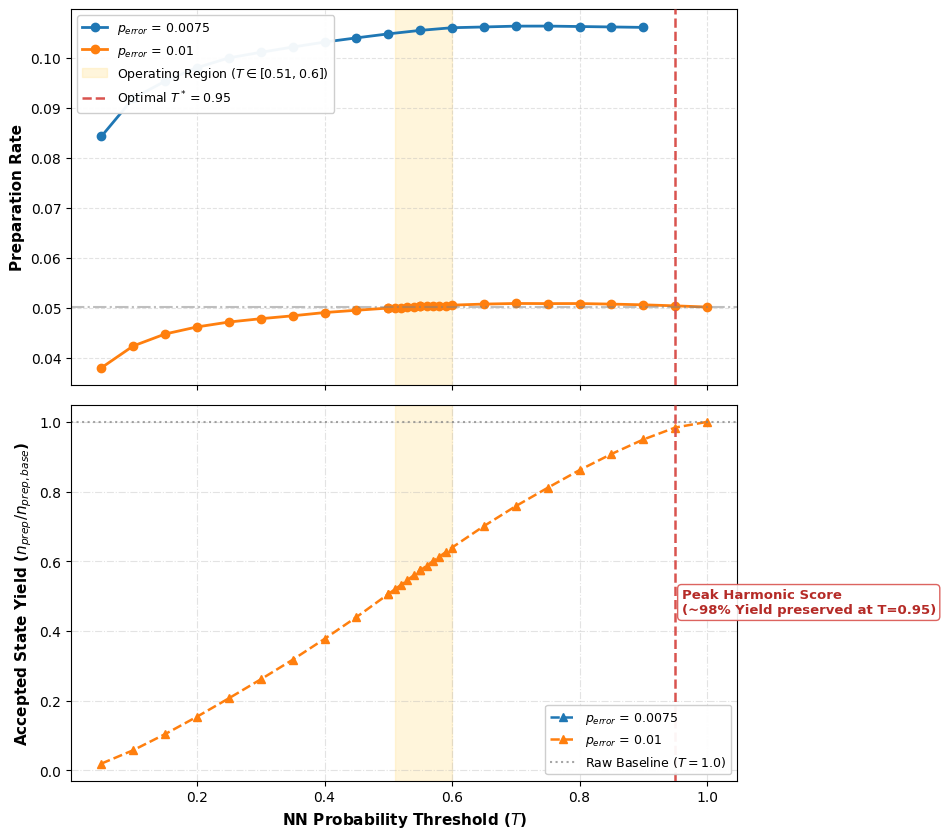

In [315]:
import matplotlib.pyplot as plt
import copy

df = copy.deepcopy(df_final)

min_t = 0.51
max_t = 0.6

# ---------------------------------------------------------
# 1. METRICS & DATA SETUP
# ---------------------------------------------------------
# Accepted State Yield (True Positive Retention Rate)
df["accepted_yield"] = df["count_accept"] / df["baseline_accept"]

# Preparation Rate (Fidelity)
df["prep_rate"] = df["count_accept"] / df["total_data"]

n_val = df["n"].iloc[0] if "n" in df.columns else 4
lstate_val = df["lstate"].iloc[0] if "lstate" in df.columns else "z"
i_val = df["i"].iloc[0] if "i" in df.columns else 7

optimal_T = np.round(optimal_global_T, 2)  # Sweet spot threshold

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 8.5), sharex=True)

# ---------------------------------------------------------
# PANEL 1: PREPARATION RATE VS THRESHOLD
# ---------------------------------------------------------
for p_err, group in df.groupby("p_error"):
    ax1.plot(
        group["prob_threshold"],
        group["prep_rate"],
        marker="o",
        linewidth=2,
        label=f"$p_{{error}}$ = {p_err}",
    )

    # Optional: Draw raw baseline prep rate per p_error
    raw_prep_rate = (group["baseline_accept"] / group["baseline_total"]).iloc[0]
    ax1.axhline(
        y=raw_prep_rate,
        linestyle="-.",
        alpha=0.5,
        color="gray"
    )

# Highlight Zone T = 0.5 to 0.6
ax1.axvspan(
    min_t,
    max_t,
    color="#ffe599",
    alpha=0.35,
    zorder=0,
    label=f"Operating Region ($T \\in [{min_t}, {max_t}]$)",
)

# Vertical Line at Optimal T
ax1.axvline(
    x=optimal_T,
    color="#d9534f",
    linestyle="--",
    linewidth=1.8,
    zorder=4,
    label=f"Optimal $T^* = {optimal_T}$",
)

ax1.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# ax1.set_title(
#     f"n = {n_val}, State = {lstate_val}, i = {i_val} | QED NN Filter Performance",
#     fontsize=13,
#     fontweight="bold",
#     pad=12,
# )
ax1.grid(True, linestyle="--", alpha=0.35)
ax1.legend(fontsize=9, loc="upper left", framealpha=0.95)

# ---------------------------------------------------------
# PANEL 2: ACCEPTED STATE YIELD VS THRESHOLD
# ---------------------------------------------------------
for p_err, group in df.groupby("p_error"):
    ax2.plot(
        group["prob_threshold"],
        group["accepted_yield"],
        marker="^",
        linestyle="--",
        linewidth=1.8,
        label=f"$p_{{error}}$ = {p_err}",
    )

# Highlight Zone T = 0.5 to 0.6
ax2.axvspan(min_t, max_t, color="#ffe599", alpha=0.35, zorder=0)

# Vertical Line at Optimal T
ax2.axvline(x=optimal_T, color="#d9534f", linestyle="--", linewidth=1.8, zorder=4)

# Raw Baseline Reference (100% accepted states)
ax2.axhline(
    y=1.0,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    alpha=0.7,
    label="Raw Baseline ($T=1.0$)",
)

# Text Annotation inside Panel 2
ax2.text(
    x=optimal_T + 0.01,
    y=0.45,
    s=f"Peak Harmonic Score\n(~98% Yield preserved at T={optimal_T})",
    color="#b52b27",
    fontsize=9.5,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#d9534f", alpha=0.9),
)

ax2.set_xlabel("NN Probability Threshold ($T$)", fontsize=11, fontweight="bold")
ax2.set_ylabel(
    "Accepted State Yield ($n_{prep} / n_{prep, base}$)",
    fontsize=11,
    fontweight="bold",
)
ax2.grid(True, linestyle="-.", alpha=0.35)
ax2.legend(fontsize=9, loc="lower right", framealpha=0.95)

plt.tight_layout()
plt.savefig(f"qed_filter_highlighted_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300)
plt.show()

## Second Figure

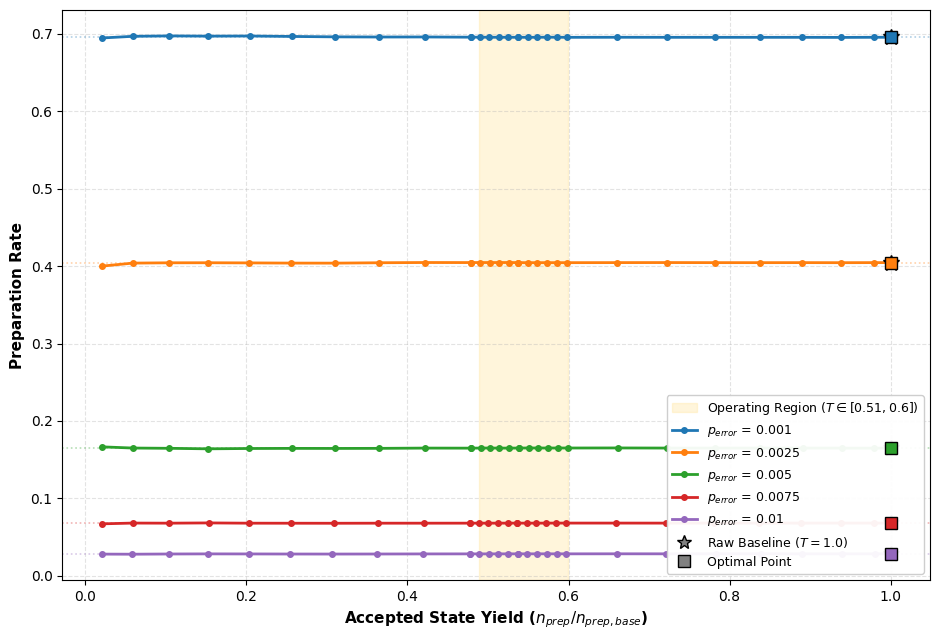

In [308]:
import matplotlib.pyplot as plt

# 1. Recalculate metrics
df["accepted_yield"] = df["count_accept"] / df["baseline_accept"]
df["prep_rate"] = df["count_accept"] / df["total_data"]

n_val = df["n"].iloc[0] if "n" in df.columns else 4
lstate_val = df["lstate"].iloc[0] if "lstate" in df.columns else "z"
i_val = df["i"].iloc[0] if "i" in df.columns else 7

fig, ax = plt.subplots(figsize=(9.5, 6.5))

# ---------------------------------------------------------
# A. HIGHLIGHT OPERATING ZONE (T in [0.5, 0.6])
# ---------------------------------------------------------
# Find min and max yield (X-axis range) corresponding to T in [0.5, 0.6]
zone_df = df[df["prob_threshold"].between(min_t, max_t)]
x_min = zone_df["accepted_yield"].min()
x_max = zone_df["accepted_yield"].max()

ax.axvspan(
    x_min,
    x_max,
    color="#ffe599",
    alpha=0.35,
    zorder=0,
    label=f"Operating Region ($T \\in [{min_t}, {max_t}]$)",
)

# ---------------------------------------------------------
# B. PLOT CURVES & HIGHLIGHT KEY THRESHOLD POINTS
# ---------------------------------------------------------
for p_err, group in df.groupby("p_error"):
    group = group.sort_values("prob_threshold")

    # Full Pareto Curve
    (line,) = ax.plot(
        group["accepted_yield"],
        group["prep_rate"],
        marker="o",
        markersize=4,
        linewidth=2,
        label=f"$p_{{error}}$ = {p_err}",
        zorder=2,
    )

    # 1. Mark Baseline Point (T = 1.0) with Star
    baseline_row = group[group["prob_threshold"] == 1.0]
    if not baseline_row.empty:
        base_prep = baseline_row["prep_rate"].values[0]
        ax.plot(
            1.0,
            base_prep,
            marker="*",
            markersize=12,
            color=line.get_color(),
            markeredgecolor="black",
            zorder=5,
        )
        ax.axhline(
            y=base_prep,
            color=line.get_color(),
            linestyle=":",
            alpha=0.35,
            linewidth=1.2,
        )

    # 2. Mark Optimal Point (T ≈ 0.57) with Square
    opt_row = group.iloc[(group["prob_threshold"] - optimal_global_T).abs().argsort()[:1]]
    if not opt_row.empty:
        opt_x = opt_row["accepted_yield"].values[0]
        opt_y = opt_row["prep_rate"].values[0]
        ax.plot(
            opt_x,
            opt_y,
            marker="s",
            markersize=8,
            color=line.get_color(),
            markeredgecolor="black",
            zorder=6,
        )

# ---------------------------------------------------------
# C. LEGEND & FORMATTING
# ---------------------------------------------------------
# Custom Legend Entries for Markers
ax.plot(
    [],
    [],
    marker="*",
    markersize=10,
    color="gray",
    markeredgecolor="black",
    linestyle="None",
    label="Raw Baseline ($T=1.0$)",
)
ax.plot(
    [],
    [],
    marker="s",
    markersize=8,
    color="gray",
    markeredgecolor="black",
    linestyle="None",
    label="Optimal Point ",
)

ax.set_xlabel(
    "Accepted State Yield ($n_{prep} / n_{prep, base}$)",
    fontsize=11,
    fontweight="bold",
)
ax.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# ax.set_title(
#     f"QED Filter Pareto Trade-off (n = {n_val}, State = {lstate_val}, i = {i_val})",
#     fontsize=12,
#     fontweight="bold",
#     pad=12,
# )

ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(
    # title="Hardware Error ($p_{error}$)",
    fontsize=9,
    loc="lower right",
    framealpha=0.95,
)

plt.tight_layout()
plt.savefig(
    f"pareto_highlighted_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300
)
plt.show()

# Back Up Code

In [ ]:
# def plot_figure(df, N_base):

#     # Normalize values so 1M shots = scale 1.0
#     df["scale_nn"] = df["total_data"] / N_base
#     df["scale_verified"] = df["count_accept"] / df["total_data"]
#     baseline_scale = baseline_count / N_base

#     fig, ax = plt.subplots(figsize=(9, 5.5))

#     # ---------------------------------------------------------
#     # A. BACKGROUND BASELINE (Faded, no legend, with text)
#     # ---------------------------------------------------------
#     ax.axhline(
#         y=baseline_scale,
#         color="gray",
#         linestyle="--",
#         linewidth=1.8,
#         alpha=0.45,  # Faded background look
#         zorder=1,
#     )
#     ax.text(
#         x=0.605,
#         y=baseline_scale * 1,
#         s=f"Normal Approach Baseline ({baseline_scale:.2%})",
#         color="#4a4a4a",
#         fontsize=9.5,
#         fontweight="bold",
#         alpha=0.8,
#         va="bottom",
#     )


#     # ---------------------------------------------------------
#     # C. SIMULATION DATA LINES
#     # ---------------------------------------------------------
#     # NN Filtered compared to 1M Base
#     ax.plot(
#         df["error_prob"],
#         df["scale_nn"],
#         marker="^",
#         color="#ff7f0e",
#         linewidth=2,
#         label="NN Filtered Shots",
#         zorder=3,
#     )

#     # Verified Accepted
#     ax.plot(
#         df["error_prob"],
#         df["scale_verified"],
#         marker="o",
#         color="#1f77b4",
#         linewidth=2,
#         label="Preparation Rate",
#         zorder=4,
#     )

#     # ---------------------------------------------------------
#     # D. FORMATTING
#     # ---------------------------------------------------------
#     # ax.set_yscale("log")
#     ax.set_ylim(bottom=df["scale_verified"].min() * 0.7, top=1)  # Cap scale at 1.0

#     ax.set_xlabel("NN Filter Error Prob", fontsize=12, fontweight="bold")
#     ax.set_ylabel(
#         "Normalized Scale (Relative to 1M Shots)", fontsize=12, fontweight="bold"
#     )
#     ax.set_title(
#         f"n = {n}, State = {lstate}, i = {i}, p = 0.005, NN Residual Block (prop-1)",
#         fontsize=13,
#         fontweight="bold",
#         pad=12,
#     )

#     ax.grid(True, which="both", linestyle="--", alpha=0.35)
#     ax.legend(fontsize=10, loc="lower right", framealpha=0.9)

#     plt.tight_layout()
#     plt.savefig(f"normalized_1m_scale_plot_{lstate}_n{n}_i{i}.png", dpi=300)
#     plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import copy

# # ---------------------------------------------------------
# # 1. DYNAMIC METRIC CALCULATIONS
# # ---------------------------------------------------------

# df = copy.deepcopy(df_final)
# df = df[
#     (df["p_error"] != 0.05) &
#     (df["p_error"] != 0.025)
# ].copy()

# # Compute shot survival scale relative to each group's baseline total
# df["scale_nn"] = df["count_accept"] / df["baseline_accept"]

# # Compute preparation rate (count_accept / total_data)
# df["prep_rate"] = df["count_accept"] / df["total_data"]

# # Extract single state info for title formatting
# n_val = df["n"].iloc[0]
# lstate_val = df["lstate"].iloc[0]
# i_val = df["i"].iloc[0]

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# # ---------------------------------------------------------
# # PANEL 1: PREPARATION RATE VS THRESHOLD
# # ---------------------------------------------------------
# for p_err, group in df.groupby("p_error"):
#     ax1.plot(
#         group["prob_threshold"],
#         group["prep_rate"],
#         marker="o",
#         linewidth=2,
#         label=f"$p_{{error}}$ = {p_err}",
#     )
    
#     # Optional: Draw raw baseline prep rate per p_error
#     raw_prep_rate = (group["baseline_accept"] / group["baseline_total"]).iloc[0]
#     ax1.axhline(
#         y=raw_prep_rate,
#         linestyle="-.",
#         alpha=0.5,
#         color="gray"
#     )

# ax1.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# ax1.set_title(
#     f"n = {n_val}, State = {lstate_val}, i = {i_val} | State Fidelity & Efficiency",
#     fontsize=13,
#     fontweight="bold",
#     pad=10,
# )
# ax1.grid(True, linestyle="--", alpha=0.35)
# ax1.legend(fontsize=9, loc="lower right")

# # ---------------------------------------------------------
# # PANEL 2: SHOT RETENTION / DATA SURVIVAL RATE
# # ---------------------------------------------------------
# for p_err, group in df.groupby("p_error"):
#     ax2.plot(
#         group["prob_threshold"],
#         group["scale_nn"],
#         marker="^",
#         linestyle="--",
#         linewidth=1.8,
#         label=f"$p_{{error}}$ = {p_err}",
#     )

# # Baseline line is y = 1.0 (100% of baseline shots retained at threshold baseline)
# ax2.axhline(
#     y=1.0,
#     color="gray",
#     linestyle="-.",
#     linewidth=1.5,
#     alpha=0.7,
#     label="Raw Baseline (100% Shots)",
# )

# ax2.set_xlabel("NN Probability Threshold", fontsize=11, fontweight="bold")
# ax2.set_ylabel(
#     "Shots Retained (Fraction of Baseline)", fontsize=11, fontweight="bold"
# )
# ax2.grid(True, linestyle="--", alpha=0.35)
# ax2.legend(fontsize=9, loc="lower right")

# plt.tight_layout()
# plt.savefig(f"nn_filter_performance_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300)
# plt.show()


In [96]:
# # ---------------------------------------------------------
# # 1. DYNAMIC METRIC CALCULATIONS
# # ---------------------------------------------------------

# df = copy.deepcopy(df_final)
# # Filter for prob_threshold between 0.5 and 0.6 (inclusive)
# df = df[
#     (df["prob_threshold"] >= 0.5) & 
#     (df["prob_threshold"] <= 0.6) &
#     (df["p_error"] != 0.05) &
#     (df["p_error"] != 0.025)
# ].copy()

# # Compute shot survival scale relative to each group's baseline total
# df["scale_nn"] = df["count_accept"] / df["baseline_accept"]

# # Compute preparation rate (count_accept / total_data)
# df["prep_rate"] = df["count_accept"] / df["total_data"]

# # Extract single state info for title formatting
# n_val = df["n"].iloc[0]
# lstate_val = df["lstate"].iloc[0]
# i_val = df["i"].iloc[0]

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# # ---------------------------------------------------------
# # PANEL 1: PREPARATION RATE VS THRESHOLD
# # ---------------------------------------------------------
# for p_err, group in df.groupby("p_error"):
#     ax1.plot(
#         group["prob_threshold"],
#         group["prep_rate"],
#         marker="o",
#         linewidth=2,
#         label=f"$p_{{error}}$ = {p_err}",
#     )
    
#     # Optional: Draw raw baseline prep rate per p_error
#     raw_prep_rate = (group["baseline_accept"] / group["baseline_total"]).iloc[0]
#     ax1.axhline(
#         y=raw_prep_rate,
#         linestyle="-.",
#         alpha=0.5,
#         color="gray"
#     )

# ax1.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# ax1.set_title(
#     f"n = {n_val}, State = {lstate_val}, i = {i_val} | State Fidelity & Efficiency",
#     fontsize=13,
#     fontweight="bold",
#     pad=10,
# )
# ax1.grid(True, linestyle="--", alpha=0.35)
# ax1.legend(fontsize=9, loc="lower right")

# # ---------------------------------------------------------
# # PANEL 2: SHOT RETENTION / DATA SURVIVAL RATE
# # ---------------------------------------------------------
# for p_err, group in df.groupby("p_error"):
#     ax2.plot(
#         group["prob_threshold"],
#         group["scale_nn"],
#         marker="^",
#         linestyle="--",
#         linewidth=1.8,
#         label=f"$p_{{error}}$ = {p_err}",
#     )

# # Baseline line is y = 1.0 (100% of baseline shots retained at threshold baseline)
# ax2.axhline(
#     y=1.0,
#     color="gray",
#     linestyle="-.",
#     linewidth=1.5,
#     alpha=0.7,
#     label="Raw Baseline (100% Shots)",
# )

# ax2.set_xlabel("NN Probability Threshold", fontsize=11, fontweight="bold")
# ax2.set_ylabel(
#     "Shots Retained (Fraction of Baseline)", fontsize=11, fontweight="bold"
# )
# ax2.grid(True, linestyle="--", alpha=0.35)
# ax2.legend(fontsize=9, loc="lower right")

# plt.tight_layout()
# plt.savefig(f"nn_filter_performance_zoomed_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300)
# plt.show()

In [97]:
# import matplotlib.pyplot as plt

# # df["accepted_yield"] = df["count_accept"] / df["baseline_accept"]
# # df["prep_rate"] = df["count_accept"] / df["total_data"]

# # n_val = df["n"].iloc[0] if "n" in df.columns else 4
# # lstate_val = df["lstate"].iloc[0] if "lstate" in df.columns else "z"
# # i_val = df["i"].iloc[0] if "i" in df.columns else 7

# # fig, ax = plt.subplots(figsize=(9, 6))

# # for p_err, group in df.groupby("p_error"):
# #     group = group.sort_values("prob_threshold")

# #     # Plot the full trade-off curve
# #     (line,) = ax.plot(
# #         group["accepted_yield"],
# #         group["prep_rate"],
# #         marker="o",
# #         markersize=5,
# #         linewidth=2,
# #         label=f"$p_{{error}}$ = {p_err}",
# #     )

# #     # 1. Mark the RAW BASELINE point (T = 1.0, where Yield = 1.0)
# #     baseline_row = group[group["prob_threshold"] == 1.0]
# #     if not baseline_row.empty:
# #         base_prep = baseline_row["prep_rate"].values[0]

# #         # Draw a star marker at X = 1.0
# #         ax.plot(
# #             1.0,
# #             base_prep,
# #             marker="*",
# #             markersize=12,
# #             color=line.get_color(),
# #             markeredgecolor="black",
# #             zorder=5,
# #         )

# #         # Draw horizontal reference line extending to X = 1.0
# #         ax.axhline(
# #             y=base_prep,
# #             color=line.get_color(),
# #             linestyle=":",
# #             alpha=0.4,
# #             linewidth=1.2,
# #         )

# # # 2. Add a dummy legend entry for the Baseline marker
# # ax.plot(
# #     [],
# #     [],
# #     marker="*",
# #     markersize=10,
# #     color="gray",
# #     markeredgecolor="black",
# #     linestyle="None",
# #     label="Raw Baseline ($T=1.0$)",
# # )



# # # Formatting
# # ax.set_xlabel(
# #     "Accepted State Yield ($N_{accept} / N_{accept, base}$)",
# #     fontsize=11,
# #     fontweight="bold",
# # )
# # ax.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# # ax.set_title(
# #     f"QED Filter Pareto Trade-off (n = {n_val}, State = {lstate_val}, i = {i_val})",
# #     fontsize=12,
# #     fontweight="bold",
# #     pad=12,
# # )

# # ax.grid(True, linestyle="--", alpha=0.35)
# # ax.legend(title="Hardware Error ($p_{error}$)", fontsize=9, loc="lower left")

# # plt.tight_layout()
# # plt.savefig(f"pareto_with_baselines_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300)
# # plt.show()